In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

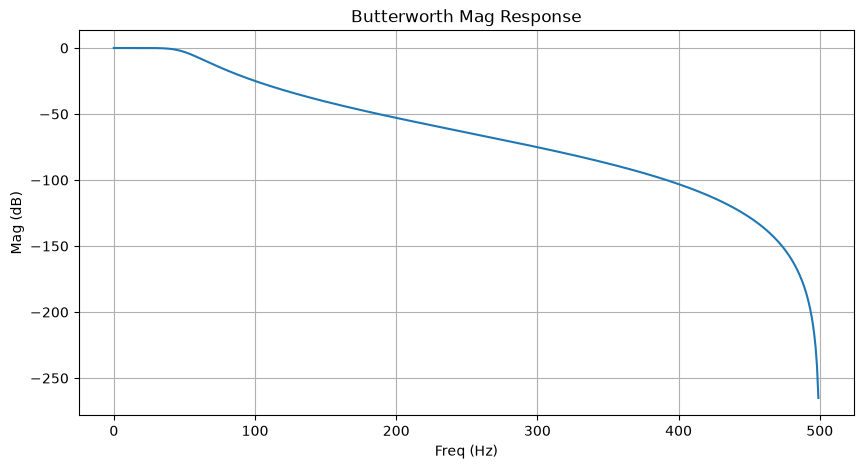

In [2]:
fs = 1000
cutoff = 50
order = 4

b , a = signal.butter(
    order,
    cutoff,
    btype='low',
    fs=fs
)

w, h = signal.freqz(b, a, fs=fs)

magnitude_db = 20*np.log10(np.abs(h))
phase = np.unwrap(np.angle(h))

plt.figure(figsize =(10, 5))
plt.plot(w, magnitude_db)
plt.xlabel('Freq (Hz)')
plt.ylabel('Mag (dB)')
plt.title("Butterworth Mag Response")
plt.grid()
plt.show()


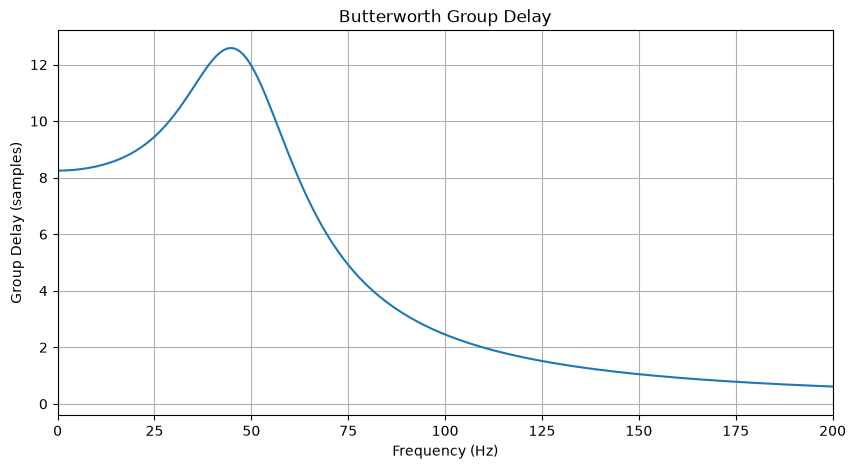

In [3]:
# group delay

f_gd, gd = signal.group_delay(
    (b,a),
    fs=fs
)

plt.figure(figsize=(10, 5))
plt.plot(f_gd, gd)
plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group Delay (samples)")
plt.title("Butterworth Group Delay")
plt.grid()
plt.show()

In [7]:
# compare to linear FIR

numtaps =41
b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff = 50,
    fs=fs
)
a_fir = [1]

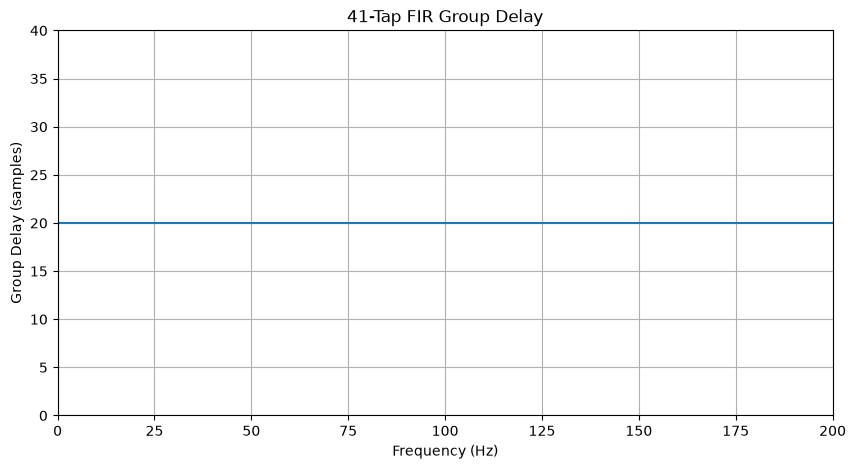

In [10]:
f_fir, gd_fir = signal.group_delay(
    (b_fir, a_fir),
    fs=fs
)

plt.figure(figsize=(10, 5))

plt.plot(f_fir, gd_fir)

plt.xlim(0, 200)
plt.ylim(0,40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Group Delay (samples)")
plt.title("41-Tap FIR Group Delay")
plt.grid()
plt.show()

In [9]:
print(gd_fir[:20])
print("min:", np.min(gd_fir))
print("max:", np.max(gd_fir))

[20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.
 20. 20.]
min: 19.999999998125304
max: 20.000000013008034


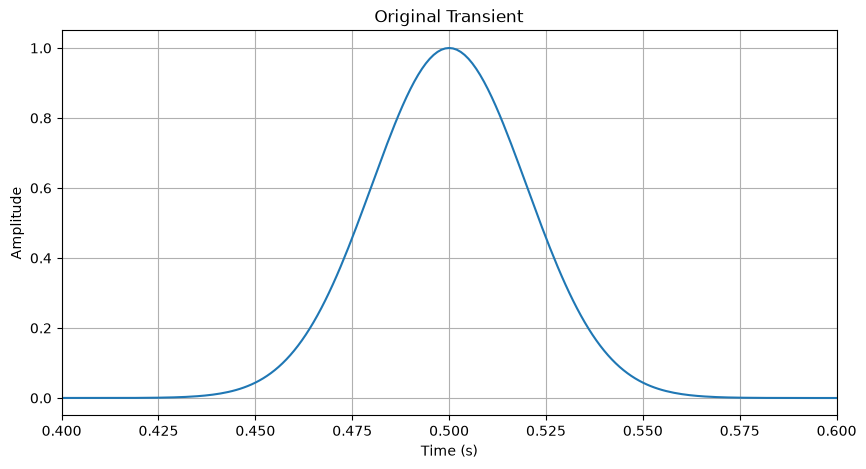

In [16]:
# pass transient signal

fs = 1000
t = np.arange(0, 1, 1/fs)

# Gaussian pulse
pulse = np.exp(-0.5 * ((t-0.5)/ 0.02)**2)
plt.figure(figsize=(10, 5))
plt.plot(t, pulse)

plt.xlim(0.4, 0.6)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original Transient")
plt.grid()
plt.show()

In [17]:
y_fir = signal.lfilter(
    b_fir,
    a_fir,
    pulse
)
y_iir = signal.lfilter(
    b,
    a,
    pulse
)

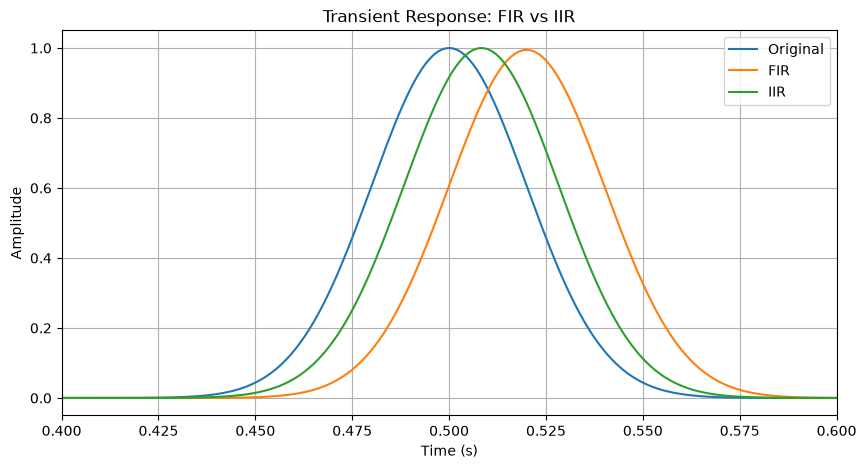

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(t, pulse, label="Original")
plt.plot(t, y_fir, label="FIR")
plt.plot(t, y_iir, label="IIR")

plt.xlim(0.4, 0.6)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Transient Response: FIR vs IIR")
plt.legend()
plt.grid()
plt.show()

In [19]:
peak_original = np.argmax(pulse)
peak_fir = np.argmax(y_fir)
peak_iir = np.argmax(y_iir)

print("Original peak:", peak_original, "samples")
print("FIR peak:", peak_fir, "samples")
print("IIR peak:", peak_iir, "samples")

print("FIR delay:",
      (peak_fir - peak_original) / fs * 1000, "ms")

print("IIR delay:",
      (peak_iir - peak_original) / fs * 1000, "ms")

Original peak: 500 samples
FIR peak: 520 samples
IIR peak: 508 samples
FIR delay: 20.0 ms
IIR delay: 8.0 ms


In [20]:
fir_delay = peak_fir - peak_original
iir_delay = peak_iir - peak_original

fir_aligned = np.roll(y_fir, -fir_delay)
iir_aligned = np.roll(y_iir, -iir_delay)

# Ignore the edges introduced by np.roll
start = 100
end = 900

fir_error = np.sqrt(np.mean((pulse[start:end] - fir_aligned[start:end])**2))
iir_error = np.sqrt(np.mean((pulse[start:end] - iir_aligned[start:end])**2))

print("FIR aligned RMSE:", fir_error)
print("IIR aligned RMSE:", iir_error)

FIR aligned RMSE: 0.0009281983274287106
IIR aligned RMSE: 0.0022255460927616726


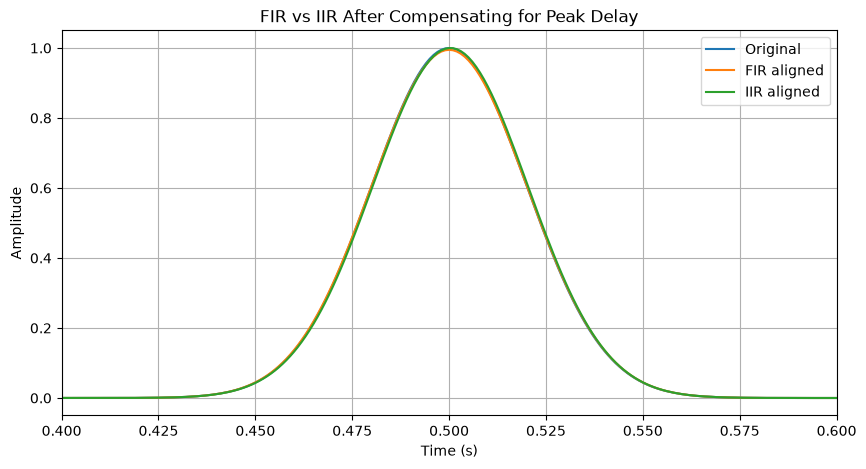

In [31]:
fir_delay = peak_fir - peak_original
iir_delay = peak_iir - peak_original

t_fir_aligned = t - fir_delay / fs
t_iir_aligned = t - iir_delay / fs


plt.figure(figsize=(10, 5))

plt.plot(t, pulse, label="Original")
plt.plot(t_fir_aligned, y_fir, label="FIR aligned")
plt.plot(t_iir_aligned, y_iir, label="IIR aligned")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("FIR vs IIR After Compensating for Peak Delay")
plt.legend()
plt.grid()
plt.show()

In [30]:
fir_corr = np.corrcoef(pulse[start:end], fir_aligned[start:end])[0, 1]
iir_corr = np.corrcoef(pulse[start:end], iir_aligned[start:end])[0, 1]

print("FIR correlation:", fir_corr)
print("IIR correlation:", iir_corr)

FIR correlation: 0.9999923862123021
IIR correlation: 0.9999386759774164


In [23]:
np.corrcoef(pulse[start:end], fir_aligned[start:end])

array([[1.        , 0.99999239],
       [0.99999239, 1.        ]])

In [24]:
# filtfilt 
y_iir_zero = signal.filtfilt(b, a, pulse)

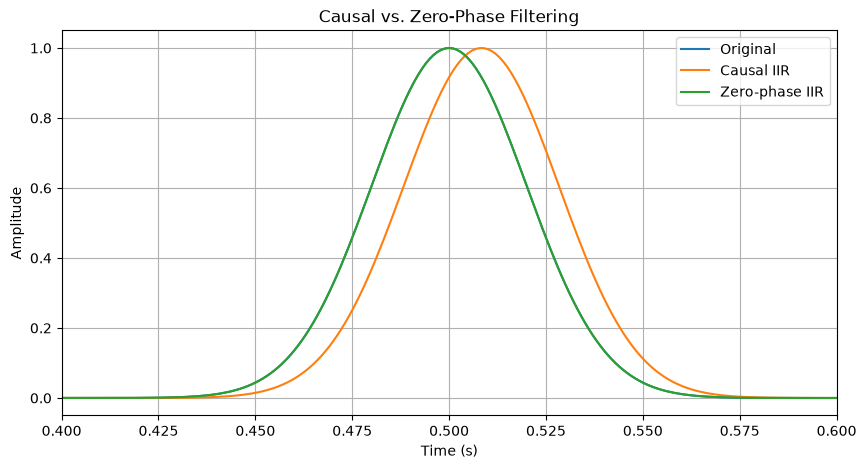

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(t, pulse, label="Original")
plt.plot(t, y_iir, label="Causal IIR")
plt.plot(t, y_iir_zero, label="Zero-phase IIR")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Causal vs. Zero-Phase Filtering")
plt.legend()
plt.grid()
plt.show()

In [32]:
fs = 1000
t = np.arange(0, 1, 1/fs)

# Gaussian transient
pulse = np.exp(-0.5 * ((t - 0.5) / 0.02)**2)

In [33]:
y_causal = signal.lfilter(b, a, pulse)

y_zero = signal.filtfilt(b, a, pulse)

In [34]:
peak_original = np.argmax(pulse)
peak_causal = np.argmax(y_causal)
peak_zero = np.argmax(y_zero)

t_original = peak_original / fs
t_causal = peak_causal / fs
t_zero = peak_zero / fs

print("Original peak:", t_original * 1000, "ms")
print("Causal peak:", t_causal * 1000, "ms")
print("Zero-phase peak:", t_zero * 1000, "ms")

print("Causal timing error:",
      (t_causal - t_original) * 1000, "ms")

print("Zero-phase timing error:",
      (t_zero - t_original) * 1000, "ms")

Original peak: 500.0 ms
Causal peak: 508.0 ms
Zero-phase peak: 500.0 ms
Causal timing error: 8.000000000000007 ms
Zero-phase timing error: 0.0 ms


In [35]:
# timing error with noise
fs = 1000
t = np.arange(0, 1, 1/fs)

pulse = np.exp(-0.5 * ((t - 0.5) / 0.02)**2)

np.random.seed(42)
noise = 0.3 * np.random.randn(len(t))

x_noisy = pulse + noise

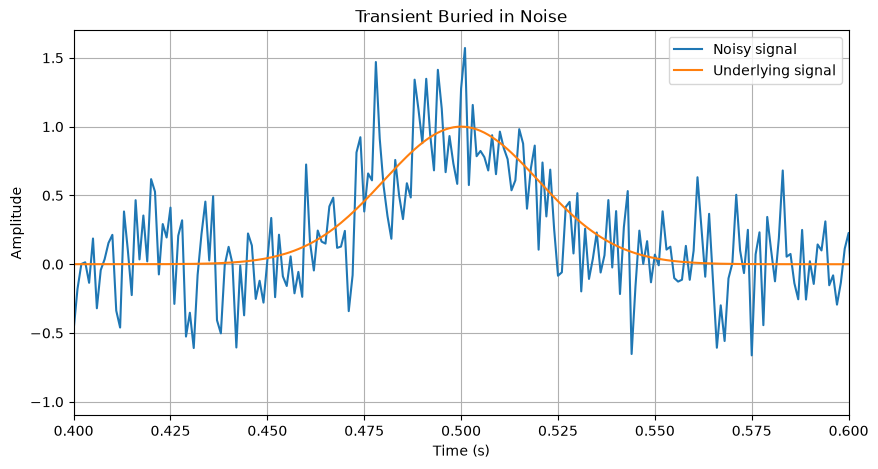

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(t, x_noisy, label="Noisy signal")
plt.plot(t, pulse, label="Underlying signal")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Transient Buried in Noise")
plt.legend()
plt.grid()
plt.show()

In [38]:
y_noisy_iir = signal.lfilter(b, a, x_noisy)

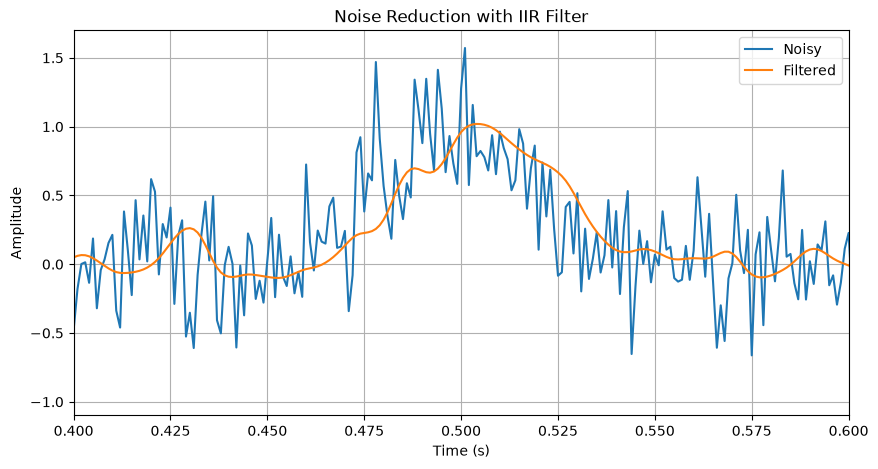

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(t, x_noisy, label="Noisy")
plt.plot(t, y_noisy_iir, label="Filtered")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Noise Reduction with IIR Filter")
plt.legend()
plt.grid()
plt.show()

In [40]:
# Quantify SNR

#define region
signal_region  = (t >= 0.46) & (t <= 0.54)
noise_region = t< 0.4

#before filter
signal_power_before = np.mean(x_noisy[signal_region]**2)
noise_power_before = np.mean(x_noisy[noise_region]**2)

snr_before = 10 * np.log10(signal_power_before/noise_power_before)

# after filter
signal_power_after = np.mean(y_noisy_iir[signal_region]**2)
noise_power_after = np.mean(y_noisy_iir[noise_region]**2)

snr_after = 10 * np.log10(
    signal_power_after / noise_power_after
)

print("SNR before:", snr_before, "dB")
print("SNR after:", snr_after, "dB")

SNR before: 7.654492142549804 dB
SNR after: 17.307102897472188 dB
